In [1]:
# ============================================================
# 1. LOAD DATA & DEFINE FEATURE GROUPS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ------------------------------------------------------------
# Load feature-engineered dataset
# ------------------------------------------------------------

DATA_PATH = Path(
    "../data/processed/feature_engineered_data.csv"
)

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = (
    df.sort_values(["Date", "Symbol"])
      .reset_index(drop=True)
)

target = "Target_Direction"


# ------------------------------------------------------------
# Base Features — 32
# ------------------------------------------------------------

base_features = [

    # Returns
    "Daily_Return",
    "Log_Return",
    "Intraday_Return",
    "High_Low_Range",

    # Return Lags
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Return_Lag_5",
    "Return_Lag_10",

    # Trend
    "Price_SMA_5_Ratio",
    "Price_SMA_10_Ratio",
    "Price_SMA_20_Ratio",
    "Price_SMA_50_Ratio",
    "Price_SMA_100_Ratio",
    "Price_SMA_200_Ratio",

    # Momentum
    "Momentum_5",
    "Momentum_10",
    "Momentum_20",

    # RSI
    "RSI_14",

    # MACD
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",

    # Bollinger
    "BB_Position",

    # Volatility
    "Volatility_5",
    "Volatility_10",
    "Volatility_20",
    "Volatility_30",

    # Volume
    "Volume_Change",
    "Relative_Volume",

    # Calendar
    "Month",
    "DayOfWeek",
    "Quarter"
]


# ------------------------------------------------------------
# Advanced Features — 16
# ------------------------------------------------------------

advanced_features = [

    # Price Action
    "Gap_Return",
    "Close_Position",

    # Rolling Return Behaviour
    "Mean_Return_5",
    "Mean_Return_10",
    "Mean_Return_20",

    # Return Distribution
    "Return_Skew_20",
    "Return_Min_20",
    "Return_Max_20",

    # Volatility / Range
    "ATR_14_Pct",

    # Long-Term Position
    "Distance_52W_High",
    "Position_52W",

    # Market Context
    "Market_Return_LOO",
    "Relative_Market_Return_LOO",

    # Sector Context
    "Sector_Return_LOO",
    "Relative_Sector_Return_LOO",

    # Market Breadth
    "Market_Breadth_LOO"
]


all_features = (
    base_features
    + advanced_features
)


print("Base Features:", len(base_features))
print("Advanced Features:", len(advanced_features))
print("Total Candidate Features:", len(all_features))

print("\nDataset Shape:", df.shape)

print(
    "Date Range:",
    df["Date"].min(),
    "→",
    df["Date"].max()
)

Base Features: 32
Advanced Features: 16
Total Candidate Features: 48

Dataset Shape: (235192, 99)
Date Range: 2000-01-03 00:00:00 → 2021-04-30 00:00:00


In [2]:
# ============================================================
# 2. CREATE COMMON MODELLING DATASET & TIME SPLIT
# ============================================================

model_df = df[
    ["Date", "Symbol"]
    + all_features
    + [target]
].copy()


# Remove invalid values
model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)


# Use a common sample for every feature-set comparison
model_df = (
    model_df
    .dropna(
        subset=all_features + [target]
    )
    .reset_index(drop=True)
)


print("Model Dataset Shape:", model_df.shape)

print(
    "Model Period:",
    model_df["Date"].min(),
    "→",
    model_df["Date"].max()
)


# ------------------------------------------------------------
# Chronological Split
# ------------------------------------------------------------

train_df = model_df[
    model_df["Date"] < "2018-01-01"
].copy()

val_df = model_df[
    (model_df["Date"] >= "2018-01-01") &
    (model_df["Date"] < "2020-01-01")
].copy()

test_df = model_df[
    model_df["Date"] >= "2020-01-01"
].copy()


print("\nTRAIN")
print(
    train_df["Date"].min(),
    "→",
    train_df["Date"].max(),
    train_df.shape
)

print("\nVALIDATION")
print(
    val_df["Date"].min(),
    "→",
    val_df["Date"].max(),
    val_df.shape
)

print("\nTEST — LOCKED")
print(
    test_df["Date"].min(),
    "→",
    test_df["Date"].max(),
    test_df.shape
)

Model Dataset Shape: (202058, 51)
Model Period: 2001-01-02 00:00:00 → 2021-04-29 00:00:00

TRAIN
2001-01-02 00:00:00 → 2017-12-29 00:00:00 (165890, 51)

VALIDATION
2018-01-01 00:00:00 → 2019-12-31 00:00:00 (21604, 51)

TEST — LOCKED
2020-01-01 00:00:00 → 2021-04-29 00:00:00 (14564, 51)


In [3]:
X_train = train_df[all_features]
y_train = train_df[target].astype(int)

X_val = val_df[all_features]
y_val = val_df[target].astype(int)

X_test = test_df[all_features]
y_test = test_df[target].astype(int)

print("\nShapes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Shapes:
Train: (165890, 48)
Validation: (21604, 48)
Test: (14564, 48)


In [4]:
# ============================================================
# 3. BASE FEATURES VS ADVANCED FEATURES
# ============================================================

initial_feature_sets = {

    "Base 32":
        base_features,

    "Base + Advanced 48":
        all_features
}


initial_results = []


for name, feature_set in initial_feature_sets.items():

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        train_df[feature_set],
        y_train
    )

    pred = model.predict(
        val_df[feature_set]
    )

    prob = model.predict_proba(
        val_df[feature_set]
    )[:, 1]


    initial_results.append({

        "Feature_Set": name,

        "N_Features":
            len(feature_set),

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred
            ),

        "Recall":
            recall_score(
                y_val,
                pred
            ),

        "F1":
            f1_score(
                y_val,
                pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                prob
            )
    })


initial_comparison = (
    pd.DataFrame(initial_results)
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
)

initial_comparison

,Feature_Set,N_Features,Accuracy,Precision,Recall,F1,ROC_AUC
1,Base + Advanced 48,48,0.518839,0.515950,0.568962,0.541161,0.531350
0,Base 32,32,0.513007,0.509207,0.649341,0.570799,0.517079


In [5]:
# ============================================================
# 4. FEATURE CORRELATION / REDUNDANCY ANALYSIS
# ============================================================

feature_corr = (
    train_df[all_features]
    .corr()
)


upper = feature_corr.where(

    np.triu(
        np.ones(
            feature_corr.shape
        ),
        k=1
    ).astype(bool)

)


corr_pairs = (
    upper
    .stack()
    .reset_index()
)


corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]


corr_pairs["Abs_Correlation"] = (
    corr_pairs["Correlation"].abs()
)


high_corr_pairs = (
    corr_pairs[
        corr_pairs[
            "Abs_Correlation"
        ] >= 0.90
    ]
    .sort_values(
        "Abs_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Highly correlated pairs:",
    len(high_corr_pairs)
)

high_corr_pairs.head(30)

Highly correlated pairs: 6


,Feature_1,Feature_2,Correlation,Abs_Correlation
0,Momentum_5,Mean_Return_5,0.998680,0.998680
1,Momentum_10,Mean_Return_10,0.997403,0.997403
2,Momentum_20,Mean_Return_20,0.994920,0.994920
3,Month,Quarter,0.971284,0.971284
4,MACD,MACD_Signal,0.951900,0.951900
5,Daily_Return,Log_Return,0.932310,0.932310


In [6]:
# ============================================================
# 5A. MUTUAL INFORMATION
# ============================================================

mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=42
)


mi_df = pd.DataFrame({

    "Feature":
        all_features,

    "MI_Score":
        mi_scores

})

In [7]:
# ============================================================
# 5B. RANDOM FOREST IMPORTANCE
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


rf.fit(
    X_train,
    y_train
)


rf_df = pd.DataFrame({

    "Feature":
        all_features,

    "RF_Importance":
        rf.feature_importances_

})

In [8]:
# ============================================================
# 5C. XGBOOST IMPORTANCE
# ============================================================

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


xgb.fit(
    X_train,
    y_train
)


xgb_df = pd.DataFrame({

    "Feature":
        all_features,

    "XGB_Importance":
        xgb.feature_importances_

})

In [9]:
# ============================================================
# 5D. COMBINED FEATURE RANKING
# ============================================================

importance_df = (
    mi_df
    .merge(
        rf_df,
        on="Feature"
    )
    .merge(
        xgb_df,
        on="Feature"
    )
)


importance_df["MI_Rank"] = (
    importance_df["MI_Score"]
    .rank(
        ascending=False,
        method="average"
    )
)


importance_df["RF_Rank"] = (
    importance_df["RF_Importance"]
    .rank(
        ascending=False,
        method="average"
    )
)


importance_df["XGB_Rank"] = (
    importance_df["XGB_Importance"]
    .rank(
        ascending=False,
        method="average"
    )
)


importance_df["Average_Rank"] = (

    importance_df[
        [
            "MI_Rank",
            "RF_Rank",
            "XGB_Rank"
        ]
    ]
    .mean(axis=1)

)


final_ranking = (
    importance_df
    .sort_values(
        "Average_Rank"
    )
    .reset_index(drop=True)
)


final_ranking[
    [
        "Feature",
        "MI_Score",
        "RF_Importance",
        "XGB_Importance",
        "Average_Rank"
    ]
].head(25)

,Feature,MI_Score,RF_Importance,XGB_Importance,Average_Rank
0,Market_Return_LOO,0.002864,0.058067,0.033890,2.000000
1,Market_Breadth_LOO,0.006729,0.046685,0.029433,2.666667
2,DayOfWeek,0.003713,0.023276,0.030867,4.666667
3,Price_SMA_10_Ratio,0.001150,0.024207,0.033628,7.333333
4,Return_Lag_1,0.001659,0.027836,0.023991,7.666667
5,Relative_Sector_Return_LOO,0.000806,0.024363,0.026059,10.333333
6,Momentum_5,0.001393,0.022153,0.025389,10.333333
7,Sector_Return_LOO,0.000056,0.034619,0.026474,13.666667
8,ATR_14_Pct,0.001101,0.018889,0.022342,16.666667
9,Price_SMA_5_Ratio,0.000626,0.023310,0.020238,17.000000


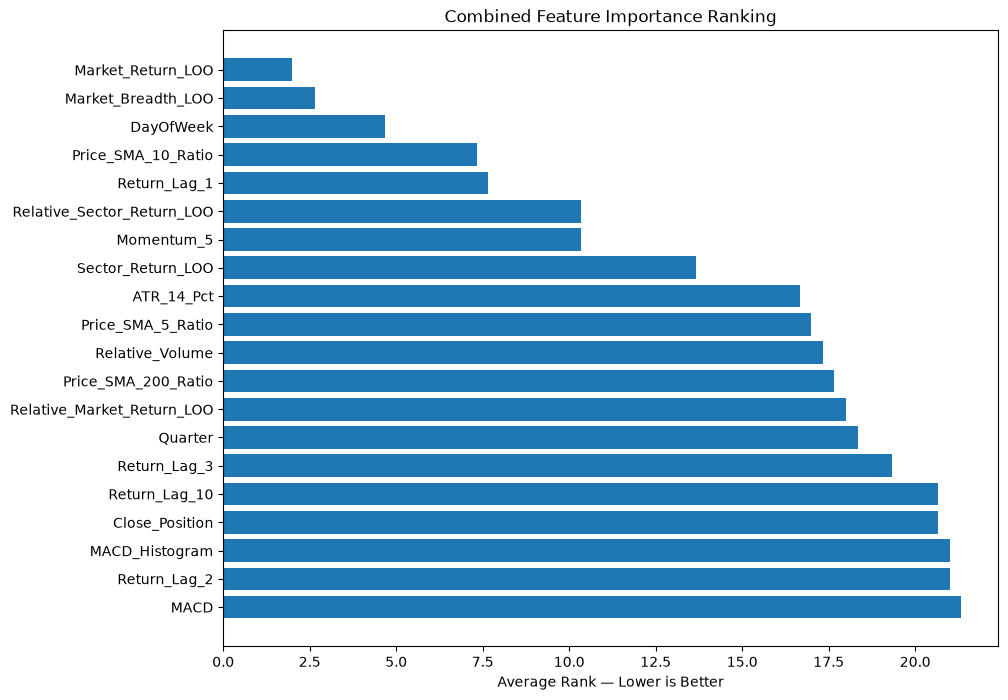

In [10]:
top20 = final_ranking.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["Feature"][::-1],
    top20["Average_Rank"][::-1]
)

plt.xlabel(
    "Average Rank — Lower is Better"
)

plt.title(
    "Combined Feature Importance Ranking"
)

plt.show()

In [11]:
top10_features = (
    final_ranking
    .head(10)["Feature"]
    .tolist()
)

top10_features = (
    final_ranking
    .head(10)["Feature"]
    .tolist()
)

top15_features = (
    final_ranking
    .head(15)["Feature"]
    .tolist()
)

top20_features = (
    final_ranking
    .head(20)["Feature"]
    .tolist()
)

top30_features = (
    final_ranking
    .head(30)["Feature"]
    .tolist()
)

In [12]:
correlation_filtered = []


for feature in final_ranking["Feature"]:

    redundant = False

    for selected in correlation_filtered:

        correlation = abs(
            train_df[feature]
            .corr(
                train_df[selected]
            )
        )

        if correlation >= 0.90:

            redundant = True
            break


    if not redundant:

        correlation_filtered.append(
            feature
        )


print(
    "Original:",
    len(all_features)
)

print(
    "Correlation Filtered:",
    len(correlation_filtered)
)

Original: 48
Correlation Filtered: 42


In [13]:
candidate_feature_sets = {

    "Base 32":
        base_features,

    "All 48":
        all_features,

    "Top 10":
        top10_features,

    "Top 15":
        top15_features,

    "Top 20":
        top20_features,

    "Top 30":
        top30_features,

    "Correlation Filtered":
        correlation_filtered
}

In [14]:
feature_set_results = []


for name, feature_set in candidate_feature_sets.items():

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )


    model.fit(
        train_df[feature_set],
        y_train
    )


    pred = model.predict(
        val_df[feature_set]
    )

    prob = model.predict_proba(
        val_df[feature_set]
    )[:, 1]


    feature_set_results.append({

        "Feature_Set":
            name,

        "N_Features":
            len(feature_set),

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Precision":
            precision_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                prob
            )
    })


feature_set_results_df = (
    pd.DataFrame(
        feature_set_results
    )
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


feature_set_results_df

,Feature_Set,N_Features,Accuracy,Precision,Recall,F1,ROC_AUC
0,Top 20,20,0.522218,0.518903,0.575831,0.545886,0.531751
1,All 48,48,0.518839,0.515950,0.568962,0.541161,0.531350
2,Top 30,30,0.522357,0.518878,0.580379,0.547908,0.530678
3,Correlation Filtered,42,0.520228,0.517074,0.574810,0.544416,0.529556
4,Top 15,15,0.517173,0.514437,0.567199,0.539531,0.526690
5,Top 10,10,0.517034,0.514444,0.562001,0.537172,0.526685
6,Base 32,32,0.513007,0.509207,0.649341,0.570799,0.517079


In [15]:
# ============================================================
# 7. WALK-FORWARD FEATURE-SET VALIDATION
# ============================================================

validation_years = [
    2015,
    2016,
    2017,
    2018,
    2019
]


walk_forward_results = []


for set_name, feature_set in candidate_feature_sets.items():

    for val_year in validation_years:

        fold_train = model_df[
            model_df["Date"].dt.year
            < val_year
        ]

        fold_val = model_df[
            model_df["Date"].dt.year
            == val_year
        ]


        X_fold_train = (
            fold_train[feature_set]
        )

        y_fold_train = (
            fold_train[target]
            .astype(int)
        )

        X_fold_val = (
            fold_val[feature_set]
        )

        y_fold_val = (
            fold_val[target]
            .astype(int)
        )


        # ----------------------------------
        # Majority Baseline
        # ----------------------------------

        majority_class = (
            y_fold_train
            .mode()[0]
        )


        baseline_pred = np.full(
            len(y_fold_val),
            majority_class
        )


        baseline_accuracy = (
            accuracy_score(
                y_fold_val,
                baseline_pred
            )
        )


        # ----------------------------------
        # XGBoost
        # ----------------------------------

        model = XGBClassifier(
            n_estimators=400,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=10,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        )


        model.fit(
            X_fold_train,
            y_fold_train
        )


        pred = model.predict(
            X_fold_val
        )

        prob = model.predict_proba(
            X_fold_val
        )[:, 1]


        accuracy = accuracy_score(
            y_fold_val,
            pred
        )


        walk_forward_results.append({

            "Feature_Set":
                set_name,

            "Year":
                val_year,

            "N_Features":
                len(feature_set),

            "Baseline_Accuracy":
                baseline_accuracy,

            "Accuracy":
                accuracy,

            "Accuracy_Improvement":
                accuracy
                - baseline_accuracy,

            "F1":
                f1_score(
                    y_fold_val,
                    pred,
                    zero_division=0
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_fold_val,
                    prob
                )
        })


walk_forward_df = pd.DataFrame(
    walk_forward_results
)

walk_forward_df.head()

,Feature_Set,Year,N_Features,Baseline_Accuracy,Accuracy,Accuracy_Improvement,F1,ROC_AUC
0,Base 32,2015,32,0.502933,0.508065,0.005132,0.569320,0.517844
1,Base 32,2016,32,0.507269,0.514722,0.007453,0.587582,0.520494
2,Base 32,2017,32,0.504124,0.502566,-0.001558,0.578310,0.500618
3,Base 32,2018,32,0.500277,0.520695,0.020418,0.577456,0.521929
4,Base 32,2019,32,0.497124,0.505751,0.008627,0.558429,0.512076


In [16]:
walk_forward_summary = (

    walk_forward_df

    .groupby(
        "Feature_Set"
    )

    .agg(

        N_Features=(
            "N_Features",
            "first"
        ),

        Mean_Accuracy=(
            "Accuracy",
            "mean"
        ),

        Mean_Baseline=(
            "Baseline_Accuracy",
            "mean"
        ),

        Mean_Improvement=(
            "Accuracy_Improvement",
            "mean"
        ),

        Mean_F1=(
            "F1",
            "mean"
        ),

        Mean_ROC_AUC=(
            "ROC_AUC",
            "mean"
        ),

        AUC_Std=(
            "ROC_AUC",
            "std"
        ),

        Min_AUC=(
            "ROC_AUC",
            "min"
        ),

        Max_AUC=(
            "ROC_AUC",
            "max"
        )
    )

    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )

    .reset_index()
)


walk_forward_summary

,Feature_Set,N_Features,Mean_Accuracy,Mean_Baseline,Mean_Improvement,Mean_F1,Mean_ROC_AUC,AUC_Std,Min_AUC,Max_AUC
0,Correlation Filtered,42,0.517382,0.502345,0.015036,0.546028,0.527548,0.009091,0.513824,0.537580
1,All 48,48,0.517930,0.502345,0.015585,0.547886,0.526937,0.007788,0.514515,0.534729
2,Top 20,20,0.517803,0.502345,0.015457,0.544686,0.526798,0.005094,0.519703,0.533251
3,Top 30,30,0.517217,0.502345,0.014872,0.548666,0.526036,0.005487,0.517189,0.531553
4,Top 10,10,0.517101,0.502345,0.014756,0.544781,0.524601,0.008005,0.514733,0.534286
5,Top 15,15,0.516700,0.502345,0.014355,0.541655,0.523816,0.006976,0.514569,0.533345
6,Base 32,32,0.510360,0.502345,0.008014,0.574219,0.514592,0.008673,0.500618,0.521929


In [20]:
# ============================================================
# 8. FINAL FEATURE SELECTION
# ============================================================

import json
from pathlib import Path


final_features = top20_features.copy()


print("Final Feature Set: Top 20")
print("Number of Features:", len(final_features))

print("\nSelected Features:")

for i, feature in enumerate(
    final_features,
    start=1
):
    print(f"{i:02d}. {feature}")


# ------------------------------------------------------------
# Save selected features
# ------------------------------------------------------------

FEATURE_PATH = Path(
    "../data/processed/selected_features.json"
)

with open(
    FEATURE_PATH,
    "w"
) as f:

    json.dump(
        final_features,
        f,
        indent=4
    )


print(
    "\nSelected features saved to:",
    FEATURE_PATH
)

Final Feature Set: Top 20
Number of Features: 20

Selected Features:
01. Market_Return_LOO
02. Market_Breadth_LOO
03. DayOfWeek
04. Price_SMA_10_Ratio
05. Return_Lag_1
06. Relative_Sector_Return_LOO
07. Momentum_5
08. Sector_Return_LOO
09. ATR_14_Pct
10. Price_SMA_5_Ratio
11. Relative_Volume
12. Price_SMA_200_Ratio
13. Relative_Market_Return_LOO
14. Quarter
15. Return_Lag_3
16. Return_Lag_10
17. Close_Position
18. MACD_Histogram
19. Return_Lag_2
20. MACD

Selected features saved to: ..\data\processed\selected_features.json


In [21]:
RANKING_PATH = Path(
    "../data/processed/feature_importance_ranking.csv"
)

final_ranking.to_csv(
    RANKING_PATH,
    index=False
)

print(
    "Feature ranking saved to:",
    RANKING_PATH
)

Feature ranking saved to: ..\data\processed\feature_importance_ranking.csv
